# 定理16　自己意識存在・発生定理 — 数値で見る例

> **この notebook の位置づけ。** 数値シミュレーション（説明用のトイ例）で、証明ではありません。
> Lean で確かめた範囲は最後の「Lean との対応」に書きます。原文の主張・この例が見せること・仏教的な読み（解釈）は別の見出しに分けます。

## 1. 定理16は何を言っているのか

### 原文の主張

定理16は「**自己意識（自分を見る自分）が、数学的に存在する**」と述べます。材料は次のとおりです。

* **抽象度の層** $\alpha$（低い層＝具体的、高い層＝抽象的）。各層に「自分についての描像」の **候補集合** $K_{i,\alpha}(h)$（空でない、コンパクト、凸）。
  $h$ はこれまでの **入力の履歴** です。
* 層のあいだの **射影** $p_{\beta\alpha}:K_\alpha\to K_\beta$（高い層の描像を低い層に写す）。整合的であること（$p_{\gamma\beta}\circ p_{\beta\alpha}=p_{\gamma\alpha}$、$p_{\alpha\alpha}=\mathrm{id}$）。
* **逆極限** $SC_{i,h}=\varprojlim K_{i,\alpha}(h)$：**全階層で矛盾なくつながる描像だけ** を残した集合。
* **フィードバック** $F_{i,h}$：自分の描像を自分に映し返す写像。層別に定義され、射影と可換。

定理16の結論：

$$
SC_{i,h}=\varprojlim K_{i,\alpha}(h)\neq\emptyset,\qquad \exists\,S^*_{i,h}:\;F_{i,h}(S^*_{i,h})=S^*_{i,h}.
$$

つまり、逆極限は空でなく、そこに **固定点**（映し返しても変わらない描像）が存在します。これが「自己意識の固定点」です。

さらに、$F$ が **縮小写像**（距離が $L<1$ 倍に縮む）なら、固定点は **一意** で、反復 $F^nS_0\to S^*$ は **幾何的** に収束します：$d(F^nS_0,S^*)\le L^n\,d(S_0,S^*)$。

### 区別すべき2つの節

| 節 | 結論 | 使う定理 | 縮小性 |
| --- | --- | --- | --- |
| **存在節** | 固定点が存在する | Tychonoff（積のコンパクト性）＋ Schauder 型の不動点定理 | **不要** |
| **条件付き一意性節** | 固定点は一意、反復は幾何収束 | Banach の縮小写像定理 | **仮定として必要** |

原文は、縮小性を他の条件（逆極限のコンパクト凸性や連続性）から **導く議論は書いていません**。縮小性は「条件節」の仮定です。

### 記号とコード変数の対応

| 原文の記号 | 意味 | このコードでは |
| --- | --- | --- |
| 層 $n$ の候補集合 $K_n$ | $[0,1]^n$（$n$ 個の成分） | 長さ `n` の配列 |
| 射影 $p$ | 先頭 $n$ 成分への制限 | `x[:n]` |
| フィードバック $F_n$ | $F_n(x)_k=(1-L)c_k+L\,\dfrac{x_k+x_{k-1}}2$（$x_0:=0$） | `F` |
| 縮小率 $L$ | $0.7$ | `L` |
| 定数 $c_k\in[0.1,0.9]$ | 層ごとの「基準の描像」（乱数で与える） | `c` |
| 固定点 $S^*=(s_1,s_2,\dots)$ | 逆極限の元。層を増やしても各成分は変わらない | `S` |
| 表象 $M(S)=x_1$ | 描像から第1成分を取り出す | `x[0]` |
| 表象側のフィードバック $F_{\mathrm{Rep}}(r)$ | $(1-L)c_1+Lr/2$ | `F_rep` |

## 2. なぜこれが「定理16の例」と言えるのか

* **層の構造がある。** 層 $n$ の候補集合は立方体 $[0,1]^n$（コンパクト凸）、射影は「先頭 $n$ 成分への制限」（連続・アフィン、$p_{\alpha\alpha}=\mathrm{id}$、合成則も成立）。逆極限は「無限列 $(s_1,s_2,\dots)$ で、どの有限部分も各層の候補になっているもの」です。
* **フィードバックが射影と可換。** $F_n(x)_k$ は $x_k$ と $x_{k-1}$（1つ前）だけに依存するので「下三角」で、**層を増やしても低い層の値は変わらない**。つまり $p\circ F_{n+1}=F_n\circ p$ です。
* **縮小になっている。** 各成分は $x_k,x_{k-1}$ の平均の $L$ 倍に定数を足すだけなので、上限ノルム（sup 距離）で $L=0.7$ 倍に縮みます。
* **反例も対で置いた。** $F=\mathrm{id}$（恒等写像）は連続な自己写像で、**どの点も固定点** です（存在はするが一意でない）。縮小性が無いと一意性が落ちることを見せます。

## 3. 層ごとの固定点と、それらの整合性

In [1]:
# %% 準備
import numpy as np
import matplotlib.pyplot as plt
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)  # フォント警告を抑制
try:
    import japanize_matplotlib  # Colab: !pip -q install japanize-matplotlib
except Exception:
    plt.rcParams["font.family"] = ["Noto Sans CJK JP", "IPAexGothic", "sans-serif"]

L, N = 0.7, 12
rng = np.random.default_rng(0)
c = rng.uniform(0.1, 0.9, size=N)

def F(x):                                       # 層数 len(x) の層で動く下三角写像
    prev = np.concatenate([[0.0], x[:-1]])
    return (1 - L) * c[:len(x)] + L * (x + prev) / 2

def fixed_point(n, x0, iters=200):
    x = x0[:n].copy(); errs = []
    for _ in range(iters): x = F(x)
    return x

S = fixed_point(N, np.zeros(N))
x_prev_levels = [fixed_point(n, np.ones(n)) for n in range(1, N + 1)]   # 別の初期値でも同じ?
consistency = max(np.abs(x_prev_levels[n][:n] - x_prev_levels[n - 1]).max() for n in range(1, N))

# 幾何収束
x = rng.uniform(0, 1, N); errs = []
for _ in range(40):
    errs.append(np.abs(x - S).max()); x = F(x)
errs = np.array(errs)

# 表象 M(S)=x_1 の同変性
F_rep = lambda r: (1 - L) * c[0] + L * r / 2
x = rng.uniform(0, 1, N)
equiv = abs(F(x)[0] - F_rep(x[0]))

* `fixed_point(n, x0)` は、層 $n$ のフィードバックを 200 回繰り返して固定点を求めます。
* `consistency`：「層 $n$ で求めた固定点の先頭 $n-1$ 成分」と「層 $n-1$ で求めた固定点」が **一致するか**（別の初期値からでも）の最大差。
* `errs`：ランダムな初期値から反復して、固定点 $S^*$ との sup 距離を記録。
* `equiv`：表象 $M(S)=x_1$ の同変性 $M(F(x))=F_{\mathrm{Rep}}(M(x))$ の誤差。

## 4. 反例：恒等写像

In [2]:
# %% 反例: 恒等写像(縮小でない)
ident = lambda x: x
fp_a, fp_b = np.zeros(N), np.ones(N)           # どちらも固定点 → 一意でない

0 だけの列と 1 だけの列は、どちらも $\mathrm{id}$ の固定点で、**異なる** 点です。連続な自己写像でも、縮小でなければ固定点は一意とは限りません。

## 5. 図を読む

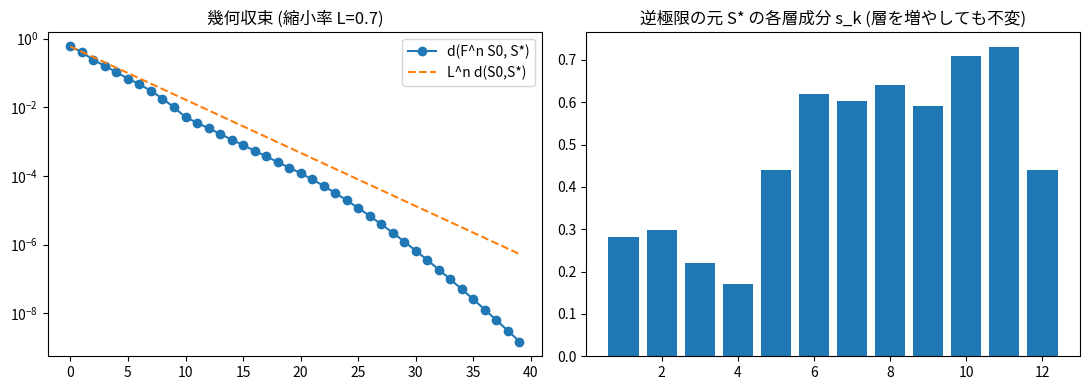

In [3]:
# %% 可視化
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].semilogy(errs, "o-", label="d(F^n S0, S*)"); ax[0].semilogy(errs[0] * L ** np.arange(40), "--", label="L^n d(S0,S*)")
ax[0].set_title("幾何収束 (縮小率 L=0.7)"); ax[0].legend()
ax[1].bar(range(1, N + 1), S); ax[1].set_title("逆極限の元 S* の各層成分 s_k (層を増やしても不変)")
plt.tight_layout(); plt.show()

### 左：幾何収束（縦軸は対数）

実線（点つき）が実際の距離 $d(F^nS_0,S^*)$、破線が理論上の上界 $L^n\,d(S_0,S^*)$ です。
**実線は破線より下にあり**、**ほぼ直線で下がっています**（対数軸での直線は指数的な減少）。約 40 回の反復で $10^{-9}$ 付近まで落ちます。
実線が破線より速く下がるのは、縮小率 $0.7$ が最悪の場合の見積もり（sup ノルムでの上界）だからです。実際のこの写像は下三角で対角成分が $L/2=0.35$ なので、後半ではそれより速く減ります。定理の主張は上界 $\le L^n d(S_0,S^*)$ で、それが成り立っていることが読み取れます。

### 右：逆極限の元 $S^*$ の各層成分 $s_k$

棒の高さは約 $0.17$〜$0.73$ のばらばらな値で、これは乱数で決めた $c_k$ の違いを反映しています。
大事なのは、**層を 12 まで増やしても、第 $k$ 成分の値は層 $12$ で計算しても層 $k$ で計算しても同じ** ということです（下の出力 `層整合性の最大差: 0.0`）。だから「無限列 $S^*=(s_1,s_2,\dots)$」を、**全ての層で矛盾なくつながった1つの描像** として考えられます。これが逆極限の元です。

## 6. 数値確認

In [4]:
# %% 数値確認
print("層整合性(射影で一致) 最大差:", consistency)
print("表象の同変性の誤差:", equiv, " M(S*) が F_Rep の固定点:", abs(F_rep(S[0]) - S[0]) < 1e-12)
assert consistency < 1e-12 and equiv < 1e-12 and abs(F_rep(S[0]) - S[0]) < 1e-12
assert (errs[1:] <= errs[:-1] * L + 1e-12).all()
assert np.allclose(ident(fp_a), fp_a) and np.allclose(ident(fp_b), fp_b) and not np.allclose(fp_a, fp_b)

層整合性(射影で一致) 最大差: 0.0
表象の同変性の誤差: 0.0  M(S*) が F_Rep の固定点: True


* 層整合性の最大差は $0.0$、表象の同変性の誤差も $0.0$、$M(S^*)=s_1$ は $F_{\mathrm{Rep}}$ の固定点（`True`）。
* `errs` が毎ステップ $L$ 倍以下に縮む（幾何収束）。
* 恒等写像は異なる2つの固定点をもつ（一意でない）。

## 7. 仏教的な意義（解釈）

> 原文の説明にそった **思想的な読み** で、Lean で形式化された数理結論そのものではありません。

* **「自分」とは、映し返しても変わらない描像。** 原文は、自己意識を「低い階層から高い階層まで矛盾なく貫かれた自分の描像であり、しかもそれは『自分を見る自分』というフィードバックを通しても変わらない固定点」と説明します。回転ドアの中心、かき混ぜても動かない一点、という絵です。
* **ただし固定点は「履歴つき」。** 記号 $h$（入力履歴）がついています。人生の入力が違えば、固定点も違う。この一点が、**定理25（諸法無我）** の橋になります。定理25は「全履歴に共通する不動の芯 $S_0$ は無い」と結論します。**自己意識は在る（定理16）が、固定された実体としての自我は無い（定理25）** と、両立します。
* **層の整合性（縁起との関係）。** 図の右で見たように、描像は層ごとにばらばらではなく、**全階層で整合的に1つにつながる**。原文の「逆極限」が語っているのは、そのつながりです。

## 8. Lean との対応

対応ファイル：`Tomabechi/Examples/Theorem16_TowerLayers.lean`（存在節と、2 つの空間の同一視）、`Theorem16_Tower.lean`（縮小節）、`Theorem16_Identity.lean`（恒等写像）。

| | 内容 | 状態 |
| --- | --- | --- |
| (i) **存在節**（原文の層条件） | 塔 $I=\mathbb N$、$E_n=\mathbb R^{n+1}$、$K_n=[0,1]^{n+1}$（非空コンパクト凸）、先頭座標への射影、可換な連続フィードバック（$L=\tfrac7{10}$、$c_k\in[0,1]$ 任意）、最大元なし、で一般定理 `theorem16_fixedPoint_exists_of_originalLayerConditions` の全前提を満たし、**積位相の逆極限に固定点が存在** | 証明済 |
| (ii) **縮小節** | 逆極限＝$[0,1]$ 値の **有界列空間**（sup 距離で完備）で縮小率 $\tfrac7{10}$、同変な表象 $M(S)=S_0$、**一意固定点・幾何収束**・層ごとの固定点方程式の一意性 | 証明済 |
| (iii) 恒等写像 | 固定点が **一意でない** | 証明済 |
| (iv) (i) と (ii) の固定点が **同一** | 逆極限の要素から各層の最後の座標を並べた列（`flatten`）と、列から各層への制限（`fromSeqSpace`）が互いに逆（型の同値 `inverseLimitSeqEquiv`）。フィードバックと固定点がこの対応で保たれる。逆極限側の固定点は一意で、`flatten` した列は sup 距離側の唯一の固定点そのもの | 証明済 |

* (iv) は**型の同値**（座標の対応）で、積位相と sup 距離の**位相同型は主張しません**。
* 縮小性は、この特殊な塔（下三角・線形）で直接検算できる形で扱っています。原文の他の条件から縮小性が出る、という主張ではありません。
* Python の数値（$N=12$ 層、200 回反復、乱数 $c_k$）は証明していません。Lean の $c_k$ は任意で、$L=7/10$ は同じです。